In [166]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KernelDensity
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import r_regression
import matplotlib.pyplot as plt
import seaborn as sns
data1 = pd.read_csv("Traffic_Volume_Counts_(Historical)_20260427.csv", engine='python', on_bad_lines='warn')
data2 = pd.read_csv("Air_Quality_and_Health_Impacts_20260427.csv")
data2.drop(columns=['Message'], inplace=True)
data2 = data2[(data2['Name'] == 'Fine particles (PM 2.5)') | (data2['Name'] == 'Nitrogen dioxide (NO2)')]
data2 = data2[data2['Time Period'].str.startswith('Annual Average')]
data2['Year'] = pd.to_numeric(data2['Time Period'].str.slice(-4))

In [167]:
data1['Year'] = pd.to_datetime(data1['Date']).dt.year
data2['Start_Date'] = pd.to_datetime(data2['Start_Date'])
min_year = max(data1['Year'].min(), data2['Year'].min())
max_year = min(data1['Year'].max(), data2['Year'].max())
data1 = data1[data1['Year'].between(min_year, max_year)]
data2 = data2[data2['Year'].between(min_year, max_year)]
print("Data 2 min year", data2['Year'].min())
print("Data 2 max year", data2['Year'].max())
print("Data 1 min year", data1['Year'].min())
print("Data 1 max year", data1['Year'].max())


Data 2 min year 2012
Data 2 max year 2021
Data 1 min year 2012
Data 1 max year 2021


In [168]:
# Handling missing values
hourly_columns = [
    '12:00-1:00 AM', '1:00-2:00AM', '2:00-3:00AM', '3:00-4:00AM', '4:00-5:00AM',
    '5:00-6:00AM', '6:00-7:00AM', '7:00-8:00AM', '8:00-9:00AM', '9:00-10:00AM',
    '10:00-11:00AM', '11:00-12:00PM', '12:00-1:00PM', '1:00-2:00PM', '2:00-3:00PM',
    '3:00-4:00PM', '4:00-5:00PM', '5:00-6:00PM', '6:00-7:00PM', '7:00-8:00PM',
    '8:00-9:00PM', '9:00-10:00PM', '10:00-11:00PM', '11:00-12:00AM'
]
data1[hourly_columns] = data1[hourly_columns].apply(pd.to_numeric, errors='coerce')
for col in hourly_columns :
    data1[col] = data1.groupby('Year')[col].transform(lambda x: x.fillna(x.mean()))
print("Total number of missing values in each columnn in data 1")
print(data1.isnull().sum())
print("Total number of missing values in each columnn in data 2")
print(data2.isnull().sum())

Total number of missing values in each columnn in data 1
ID               0
SegmentID        0
Roadway Name     0
From             0
To               0
Direction        0
Date             0
12:00-1:00 AM    0
1:00-2:00AM      0
2:00-3:00AM      0
3:00-4:00AM      0
4:00-5:00AM      0
5:00-6:00AM      0
6:00-7:00AM      0
7:00-8:00AM      0
8:00-9:00AM      0
9:00-10:00AM     0
10:00-11:00AM    0
11:00-12:00PM    0
12:00-1:00PM     0
1:00-2:00PM      0
2:00-3:00PM      0
3:00-4:00PM      0
4:00-5:00PM      0
5:00-6:00PM      0
6:00-7:00PM      0
7:00-8:00PM      0
8:00-9:00PM      0
9:00-10:00PM     0
10:00-11:00PM    0
11:00-12:00AM    0
Year             0
dtype: int64
Total number of missing values in each columnn in data 2
Unique ID         0
Indicator ID      0
Name              0
Measure           0
Measure Info      0
Geo Type Name     0
Geo Join ID       0
Geo Place Name    0
Time Period       0
Start_Date        0
Data Value        0
Year              0
dtype: int64


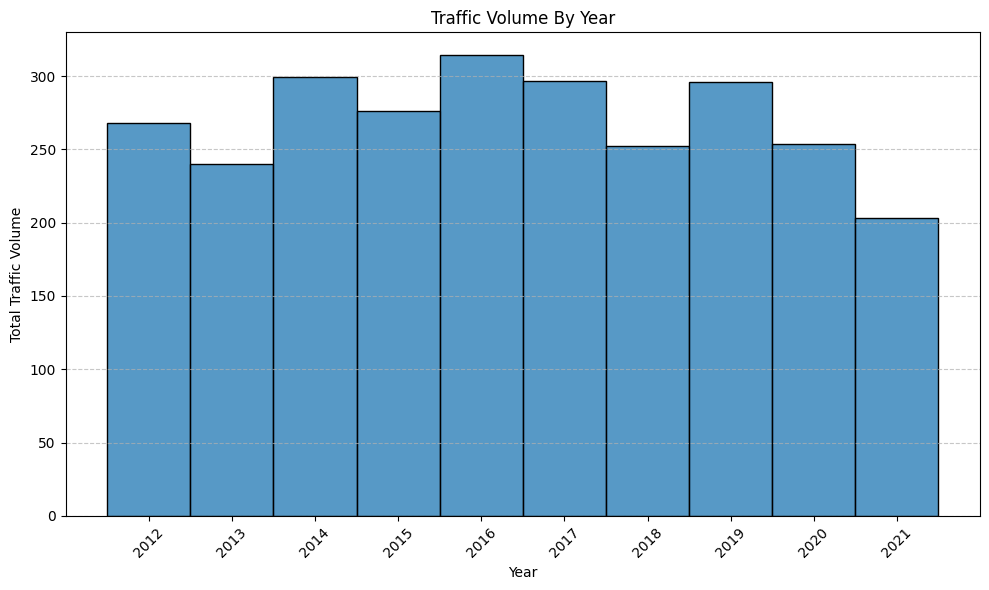

In [169]:
# Histogram for traffic counts yearly
# Convert hourly columns to numeric, coercing errors to NaN
for col in hourly_columns :
    data1[col] = pd.to_numeric(data1[col], errors='coerce')
# New column for data
data1['Daily_Traffic_Sum'] = data1[hourly_columns].mean(axis=1)
# Link traffic sums by year
yearly_traffic_summary = data1.groupby('Year')['Daily_Traffic_Sum'].mean().reset_index()
# Histogram of total traffic counts per year
plt.figure(figsize=(10, 6))
sns.histplot(data=yearly_traffic_summary, x='Year', weights='Daily_Traffic_Sum',bins=len(yearly_traffic_summary), discrete=True, shrink=1)
plt.title('Traffic Volume By Year')
plt.xlabel('Year')
plt.ylabel('Total Traffic Volume')
plt.xticks(yearly_traffic_summary['Year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


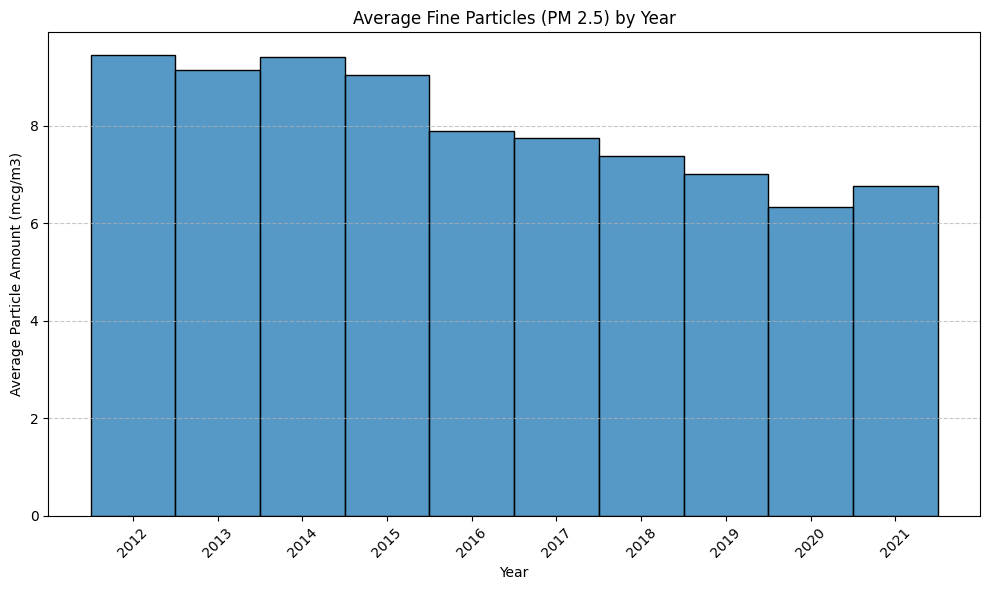

In [170]:
# Fine particles histogram
particles = data2[data2['Name'] == 'Fine particles (PM 2.5)']
particles = particles[particles['Time Period'].str.startswith('Annual Average')]
particles['Year'] = pd.to_numeric(particles['Time Period'].str.slice(-4))
particles_yearly = particles.groupby('Year')['Data Value'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.histplot(data=particles_yearly, x='Year', weights='Data Value', bins=len(particles_yearly), discrete=True, shrink=1)
plt.title('Average Fine Particles (PM 2.5) by Year')
plt.xlabel('Year')
plt.ylabel('Average Particle Amount (mcg/m3)')
plt.xticks(particles_yearly['Year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

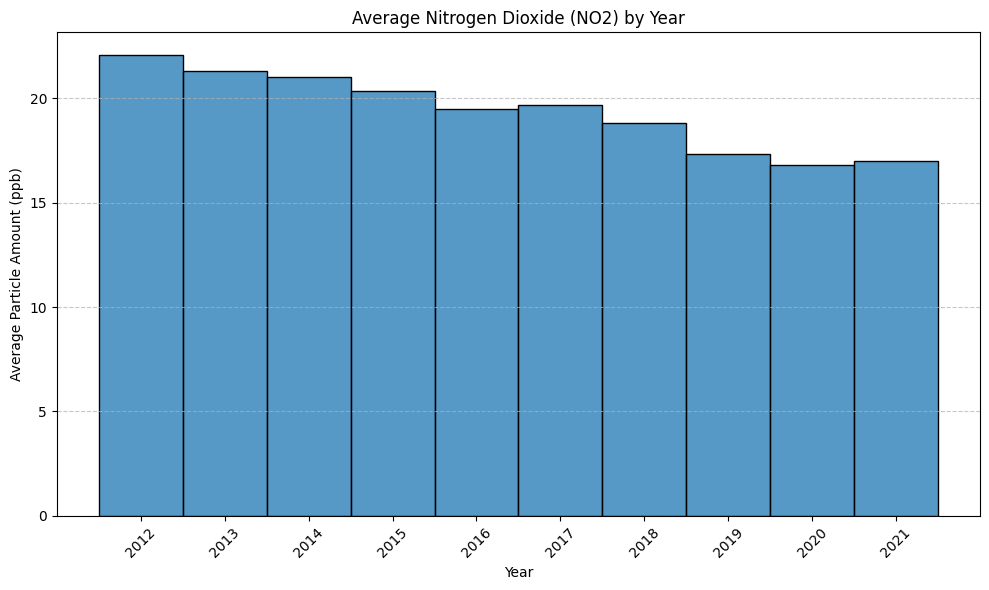

In [171]:
# NO2 histogram
no2 = data2[data2['Name'] == 'Nitrogen dioxide (NO2)']
no2 = no2[no2['Time Period'].str.startswith('Annual Average')]
no2['Year'] = pd.to_numeric(no2['Time Period'].str.slice(-4))
no2_yearly = no2.groupby('Year')['Data Value'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.histplot(data=no2_yearly, x='Year', weights='Data Value', bins=len(no2_yearly), discrete=True, shrink=1)
plt.title('Average Nitrogen Dioxide (NO2) by Year')
plt.xlabel('Year')
plt.ylabel('Average Particle Amount (ppb)')
plt.xticks(no2_yearly['Year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

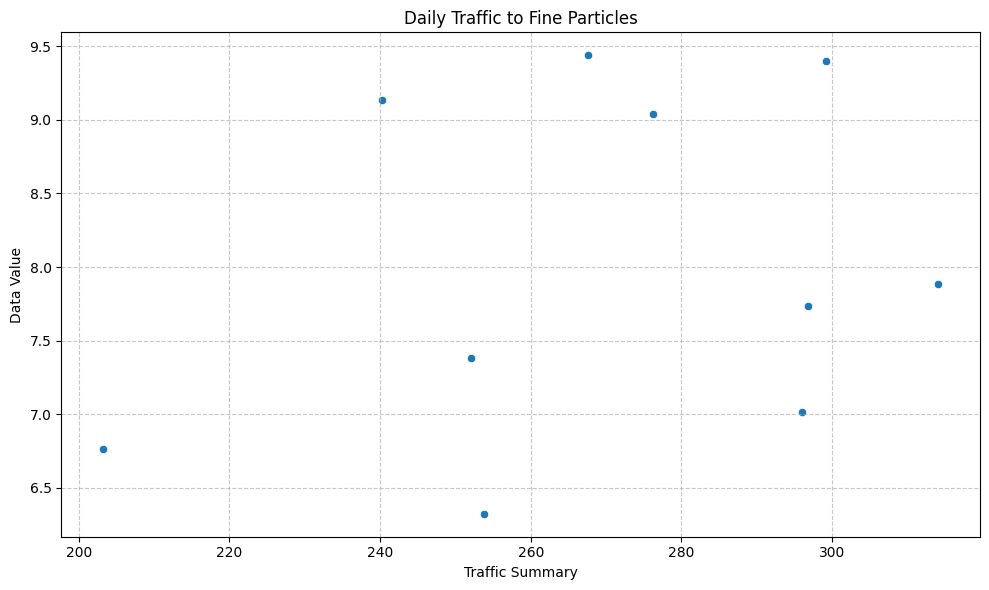

In [172]:
# scatterplot 1 (traffic_to_fp)
traffic_to_fp = pd.merge(yearly_traffic_summary, particles_yearly, on='Year')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=traffic_to_fp, x='Daily_Traffic_Sum',y='Data Value')
plt.title('Daily Traffic to Fine Particles')
plt.xlabel('Traffic Summary')
plt.ylabel('Data Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

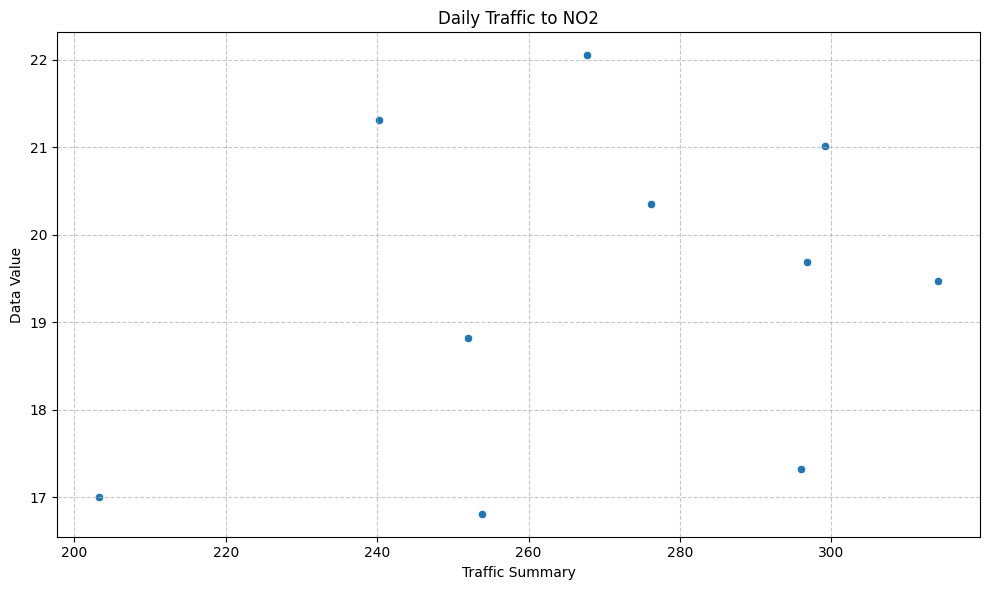

In [173]:
# scatterplot 2 (traffic_to_NO2)
traffic_to_NO2 = pd.merge(yearly_traffic_summary, no2_yearly, on='Year')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=traffic_to_NO2, x='Daily_Traffic_Sum',y='Data Value')
plt.title('Daily Traffic to NO2')
plt.xlabel('Traffic Summary')
plt.ylabel('Data Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Average Fine Particles (PM 2.5) by Daily Traffic')

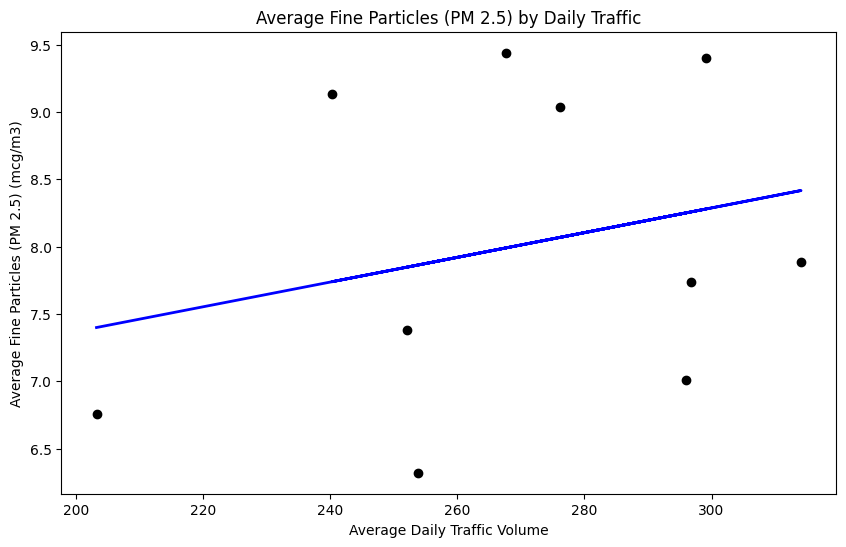

In [176]:
x = yearly_traffic_summary['Daily_Traffic_Sum'].values.reshape(-1, 1)
particles_y = particles_yearly['Data Value'].values

particles_lin_model = LinearRegression()
particles_lin_model.fit(x, particles_y)
particles_y_pred = particles_lin_model.predict(x)

plt.figure(figsize=(10,6))
plt.scatter(x, particles_y, color="black")
plt.plot(x, particles_y_pred, color="blue", linewidth=2)
plt.xlabel('Average Daily Traffic Volume')
plt.ylabel('Average Fine Particles (PM 2.5) (mcg/m3)')
plt.title("Average Fine Particles (PM 2.5) by Daily Traffic")

Text(0.5, 1.0, 'Average Nitrogen Dioxide (NO2) by Daily Traffic')

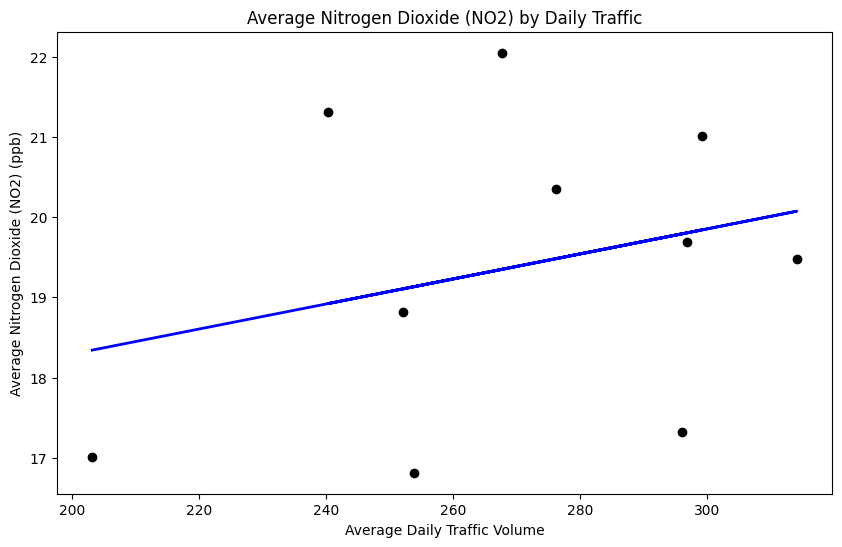

In [177]:
no2_y = no2_yearly['Data Value'].values

no2_lin_model = LinearRegression()
no2_lin_model.fit(x, no2_y)
no2_y_pred = no2_lin_model.predict(x)

plt.figure(figsize=(10,6))
plt.scatter(x, no2_y, color="black")
plt.plot(x, no2_y_pred, color="blue", linewidth=2)
plt.xlabel('Average Daily Traffic Volume')
plt.ylabel('Average Nitrogen Dioxide (NO2) (ppb)')
plt.title("Average Nitrogen Dioxide (NO2) by Daily Traffic")